# Proyecto Rappi: análisis visual y dataset filtrado

Notebook resumido para presentar la estructura del dataset, sus variables más relevantes y la distribución del tiempo de entrega.

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
pd.set_option('display.max_columns', 30)

In [4]:
file_path = 'Food_Delivery_Time_Prediction.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'dharmendrapandit12/food-delivery-time-prediction-dataset',
        file_path,
    )

df.columns = [str(column).strip() for column in df.columns]
target_col = next(
    column for column in df.columns
    if column.lower().replace('(min)', '_min').replace(' ', '_') in {'time_taken_min', 'delivery_time_min'}
)

selected_predictors = [
    'Road_Distance_km', 'Average_Speed_kmph', 'Vehicle_Type',
    'Traffic_Level', 'Delivery_Distance_Category', 'Weather',
    'Preparation_Time_Min', 'Cuisine_Type', 'Pickup_Zone',
    'Order_Hour', 'Number_of_Signals', 'Day_of_Week',
    'Is_Weekend', 'Order_Items', 'Is_Festival',
    'Rider_Experience_Years', 'Rider_Rating', 'Delivery_Priority',
    'Restaurant_Load'
]
selected_columns = selected_predictors + [target_col]
missing_columns = [column for column in selected_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f'Columnas seleccionadas ausentes: {missing_columns}')

df_filtrado = df[selected_columns].copy()
target_time = pd.to_numeric(df_filtrado[target_col], errors='coerce')

print(f'Registros: {len(df_filtrado):,}')
print(f'Columnas originales: {df.shape[1]}')
print(f'Columnas seleccionadas: {len(df_filtrado.columns)}')
print(f'Variable objetivo: {target_col}')
display(df_filtrado.head())

Registros: 50,000
Columnas originales: 24
Columnas seleccionadas: 20
Variable objetivo: Time_taken_min


,Road_Distance_km,Average_Speed_kmph,Vehicle_Type,Traffic_Level,Delivery_Distance_Category,Weather,Preparation_Time_Min,Cuisine_Type,Pickup_Zone,Order_Hour,Number_of_Signals,Day_of_Week,Is_Weekend,Order_Items,Is_Festival,Rider_Experience_Years,Rider_Rating,Delivery_Priority,Restaurant_Load,Time_taken_min
0,30.55,28.7,Scooter,Moderate,Long,Clear,23,Pizza,CBD,8,15,Tuesday,0,1,0,3.1,3.8,Normal,Medium,91
1,2.25,23.3,Scooter,Moderate,Short,Rain,11,Desserts,CBD,12,17,Friday,0,3,0,1.8,3.6,Normal,Medium,21
2,10.15,28.9,Scooter,Moderate,Long,Clear,31,Biryani,Residential,18,8,Sunday,1,1,0,3.8,3.9,Normal,Low,52
3,26.33,41.4,Bike,Low,Long,Cloudy,19,Burger,Residential,12,9,Wednesday,0,3,0,1.7,3.9,Normal,Medium,59
4,30.48,31.7,Bike,Moderate,Long,Rain,7,Desserts,Industrial,18,8,Monday,0,1,0,12.4,4.4,Normal,Medium,75


In [5]:
quality = pd.DataFrame({
    'tipo': df_filtrado.dtypes.astype(str),
    'faltantes': df_filtrado.isna().sum(),
    'unicos': df_filtrado.nunique(dropna=True)
}).sort_values(['faltantes', 'unicos'], ascending=[False, False])
display(quality)

target_metrics = target_time.describe()[['mean', '50%', 'std', 'min', 'max']].rename({
    '50%': 'mediana'
})
display(target_metrics.to_frame('minutos').round(2))

,tipo,faltantes,unicos
Road_Distance_km,float64,0,5674
Average_Speed_kmph,float64,0,393
Time_taken_min,int64,0,170
Rider_Experience_Years,float64,0,129
Preparation_Time_Min,int64,0,47
Order_Hour,int64,0,24
Rider_Rating,float64,0,19
Number_of_Signals,int64,0,17
Cuisine_Type,object,0,9
Day_of_Week,object,0,7


,minutos
mean,83.87
mediana,78.00
std,35.43
min,10.00
max,180.00


## Visualizaciones principales

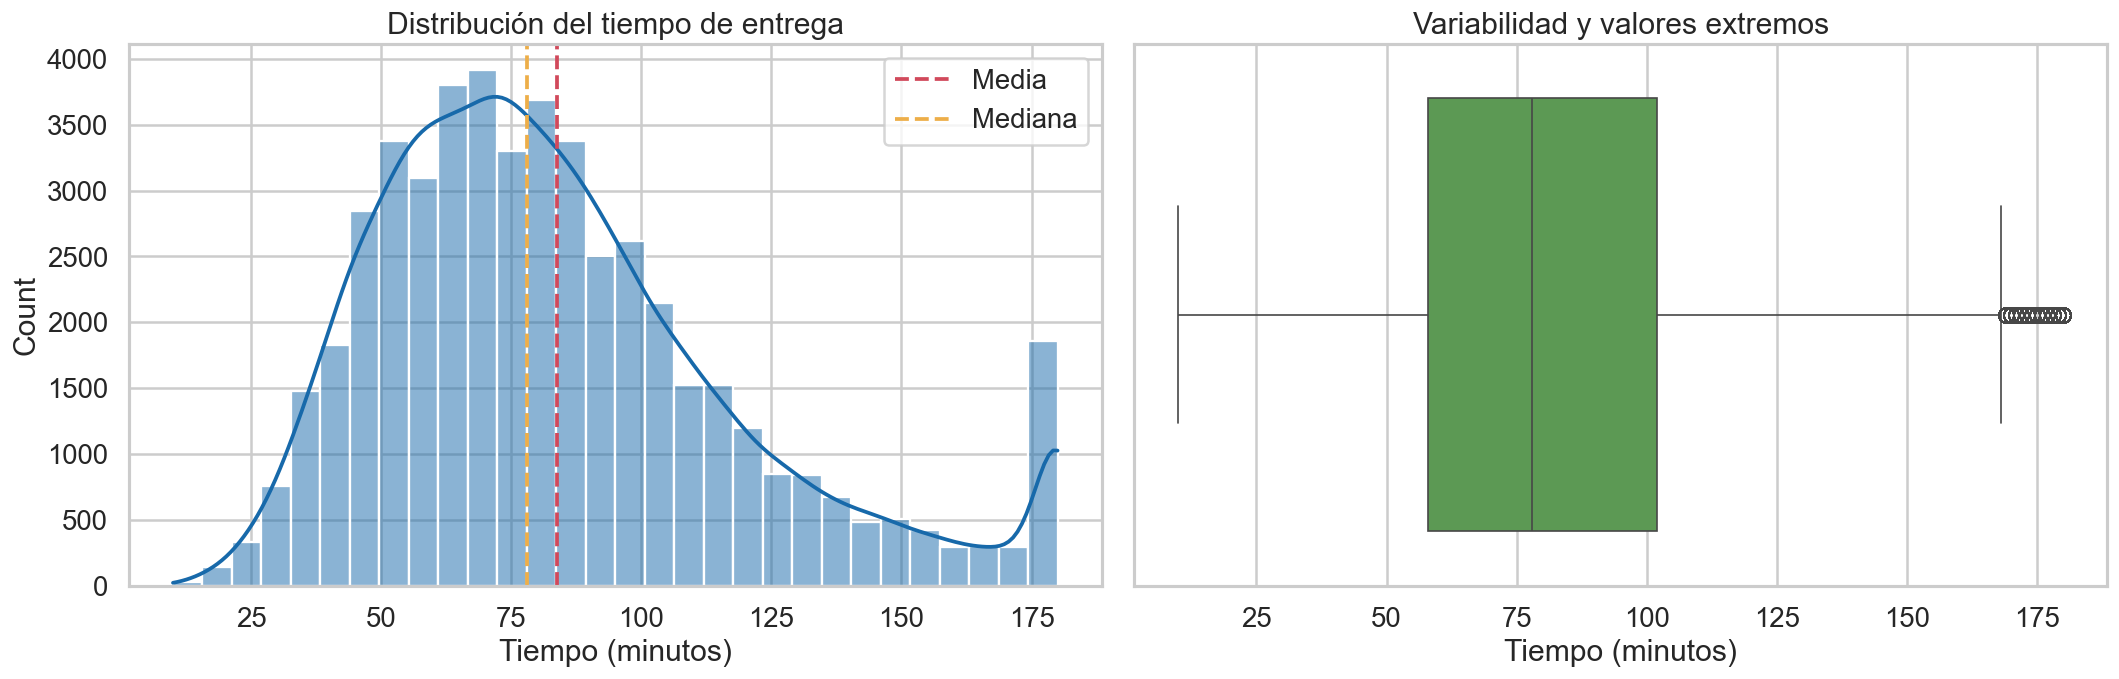

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(target_time.dropna(), bins=30, kde=True, color='#1769aa', ax=axes[0])
axes[0].axvline(target_time.mean(), color='#d1495b', linestyle='--', label='Media')
axes[0].axvline(target_time.median(), color='#edae49', linestyle='--', label='Mediana')
axes[0].set_title('Distribución del tiempo de entrega')
axes[0].set_xlabel('Tiempo (minutos)')
axes[0].legend()
sns.boxplot(x=target_time, color='#53a548', ax=axes[1])
axes[1].set_title('Variabilidad y valores extremos')
axes[1].set_xlabel('Tiempo (minutos)')
plt.tight_layout()
plt.show()

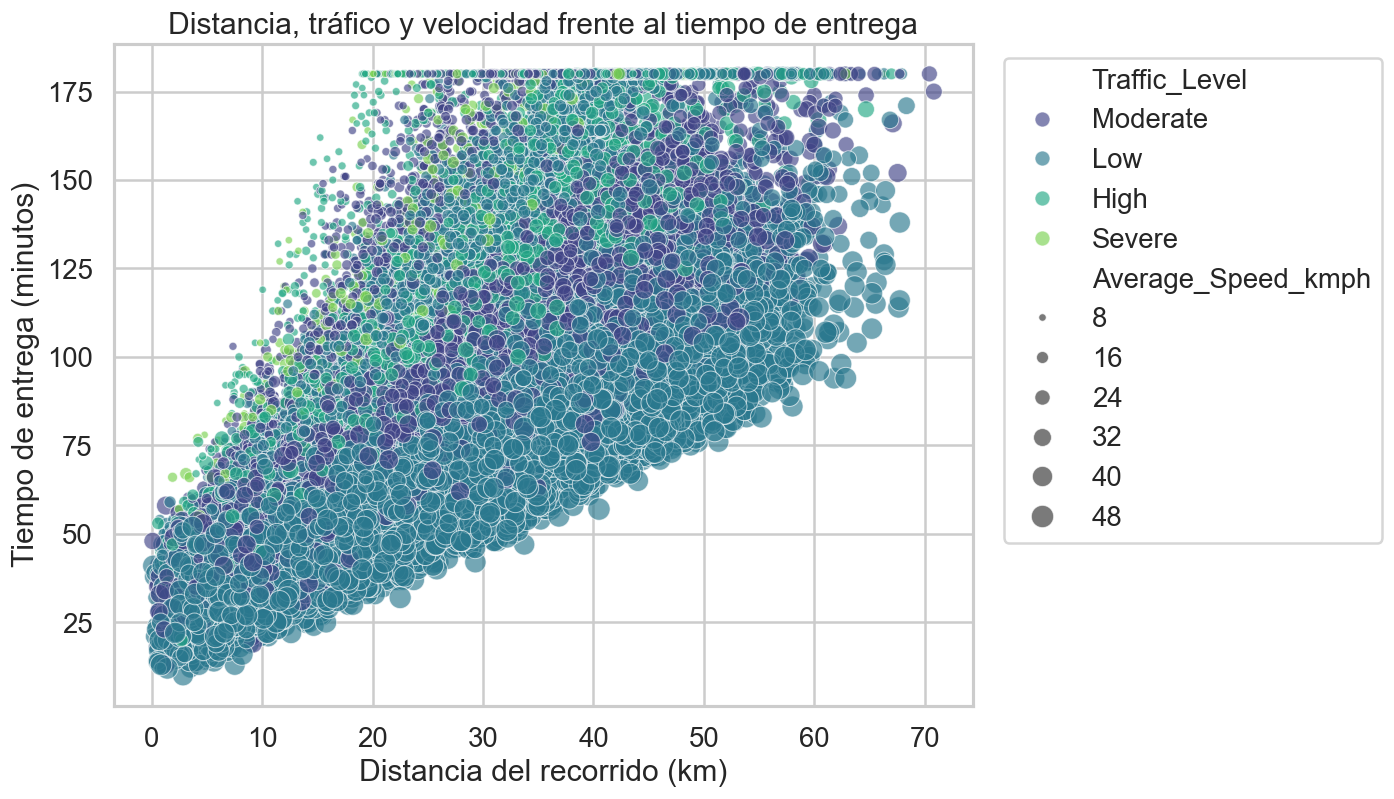

In [7]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtrado,
    x='Road_Distance_km',
    y=target_time,
    hue='Traffic_Level',
    size='Average_Speed_kmph',
    sizes=(20, 180),
    alpha=0.65,
    palette='viridis'
)
plt.title('Distancia, tráfico y velocidad frente al tiempo de entrega')
plt.xlabel('Distancia del recorrido (km)')
plt.ylabel('Tiempo de entrega (minutos)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

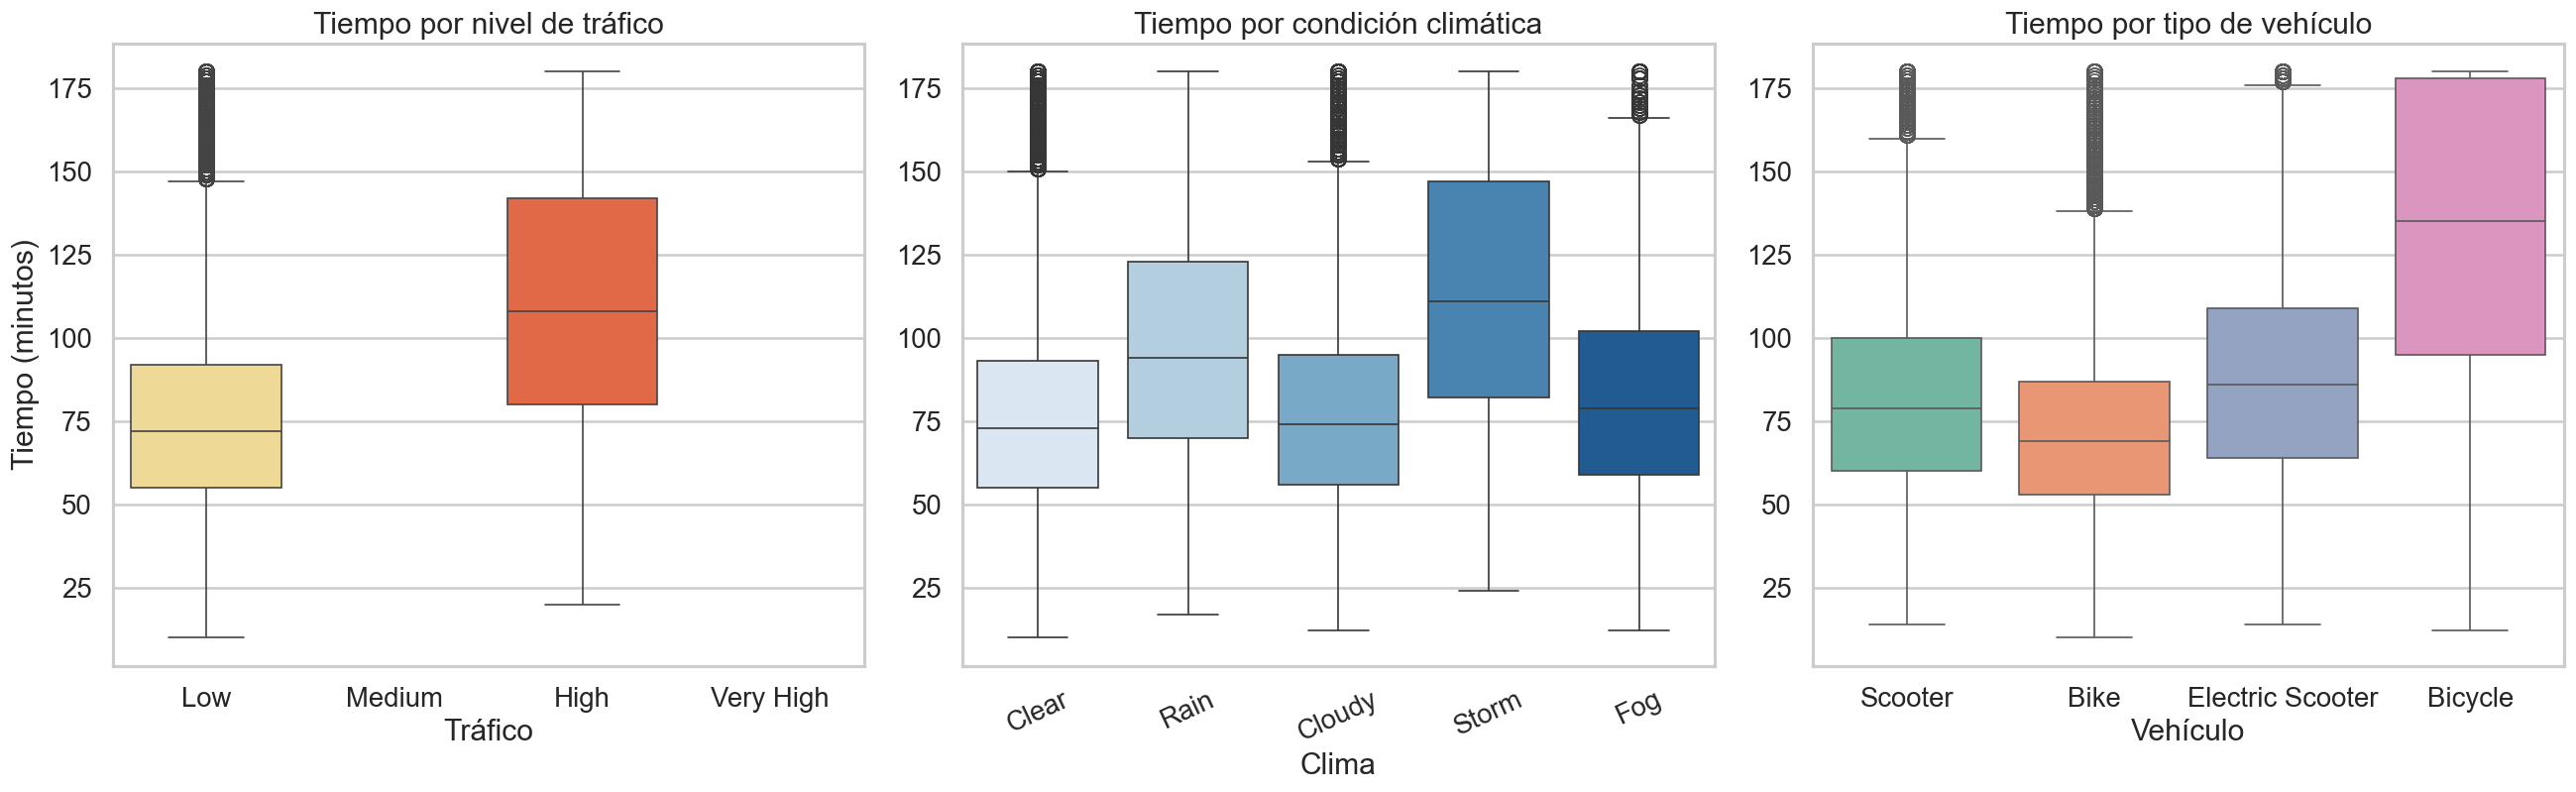

In [8]:
plot_data = df_filtrado.copy()
plot_data['target_time'] = target_time

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
sns.boxplot(data=plot_data, x='Traffic_Level', y='target_time', order=['Low', 'Medium', 'High', 'Very High'], palette='YlOrRd', ax=axes[0])
axes[0].set_title('Tiempo por nivel de tráfico')
axes[0].set_xlabel('Tráfico')
axes[0].set_ylabel('Tiempo (minutos)')
sns.boxplot(data=plot_data, x='Weather', y='target_time', palette='Blues', ax=axes[1])
axes[1].set_title('Tiempo por condición climática')
axes[1].set_xlabel('Clima')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=25)
sns.boxplot(data=plot_data, x='Vehicle_Type', y='target_time', palette='Set2', ax=axes[2])
axes[2].set_title('Tiempo por tipo de vehículo')
axes[2].set_xlabel('Vehículo')
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

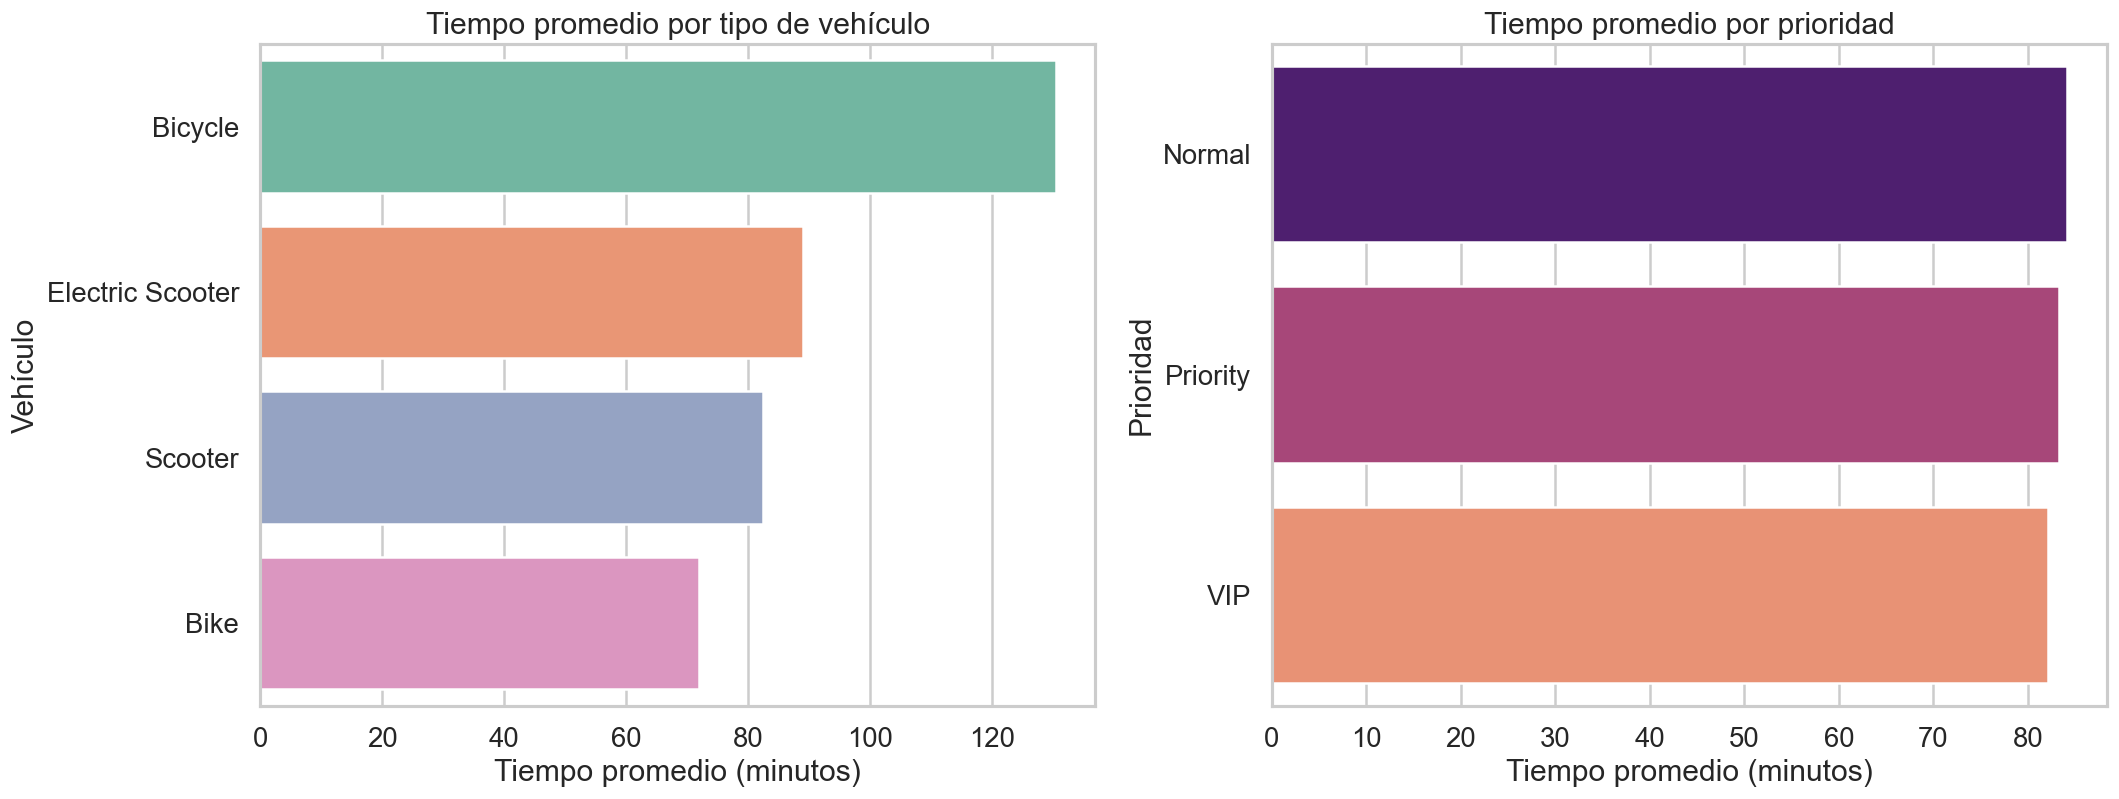

In [9]:
plot_data = df_filtrado.copy()
plot_data['target_time'] = target_time

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
vehicle_mean = plot_data.groupby('Vehicle_Type')['target_time'].mean().sort_values(ascending=False)
sns.barplot(x=vehicle_mean.values, y=vehicle_mean.index, palette='Set2', ax=axes[0])
axes[0].set_title('Tiempo promedio por tipo de vehículo')
axes[0].set_xlabel('Tiempo promedio (minutos)')
axes[0].set_ylabel('Vehículo')
priority_mean = plot_data.groupby('Delivery_Priority')['target_time'].mean().sort_values(ascending=False)
sns.barplot(x=priority_mean.values, y=priority_mean.index, palette='magma', ax=axes[1])
axes[1].set_title('Tiempo promedio por prioridad')
axes[1].set_xlabel('Tiempo promedio (minutos)')
axes[1].set_ylabel('Prioridad')
plt.tight_layout()
plt.show()

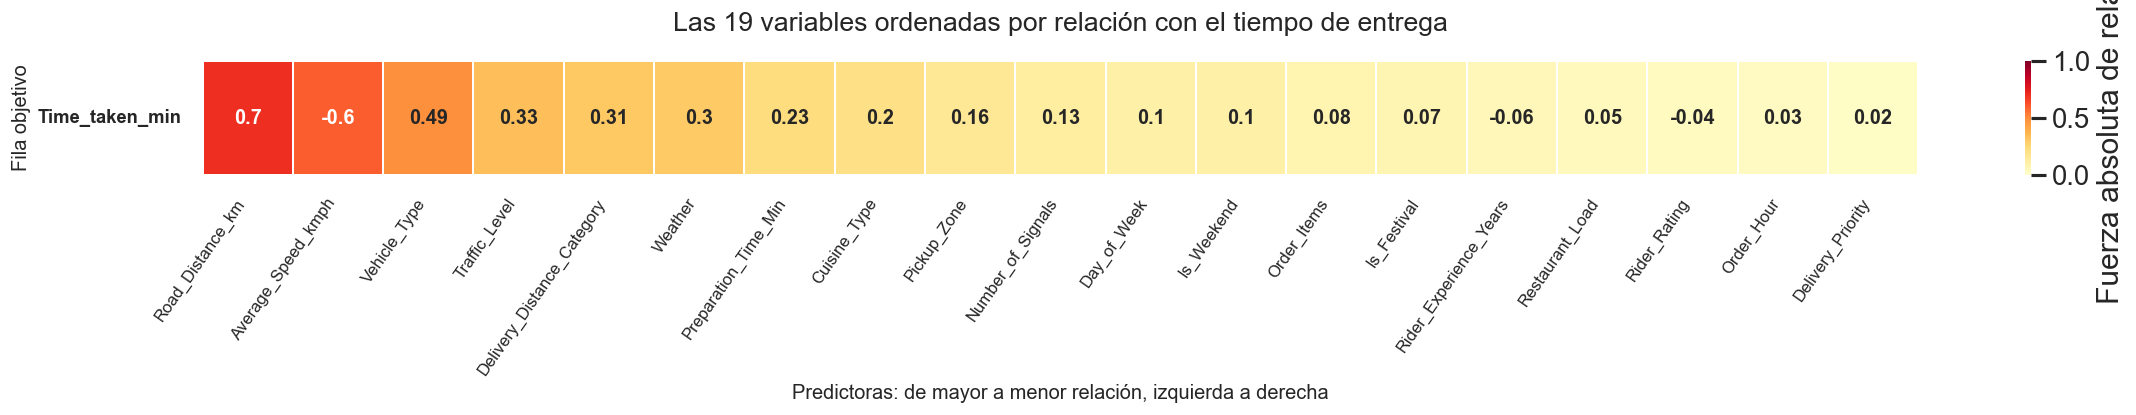

,prioridad,variable,relacion,fuerza_absoluta,metrica
0,1,Road_Distance_km,0.703,0.703,Pearson
1,2,Average_Speed_kmph,-0.596,0.596,Pearson
2,3,Vehicle_Type,0.489,0.489,Asociación categórica
3,4,Traffic_Level,0.333,0.333,Asociación categórica
4,5,Delivery_Distance_Category,0.307,0.307,Asociación categórica
5,6,Weather,0.299,0.299,Asociación categórica
6,7,Preparation_Time_Min,0.228,0.228,Pearson
7,8,Cuisine_Type,0.200,0.200,Asociación categórica
8,9,Pickup_Zone,0.158,0.158,Asociación categórica
9,10,Number_of_Signals,0.127,0.127,Pearson


In [13]:
# --- Matriz visual: relación de las 19 predictoras con el tiempo de entrega ---
def categorical_association(feature, target):
    valid = pd.DataFrame({'feature': feature, 'target': target}).dropna()
    if valid.empty or valid['feature'].nunique() < 2:
        return np.nan
    group_means = valid.groupby('feature')['target'].agg(['mean', 'count'])
    overall_mean = valid['target'].mean()
    total_variation = ((valid['target'] - overall_mean) ** 2).sum()
    explained_variation = (
        group_means['count'] * (group_means['mean'] - overall_mean) ** 2
    ).sum()
    return np.sqrt(explained_variation / total_variation) if total_variation else np.nan

association_values = {}
association_types = {}
for column in selected_predictors:
    if pd.api.types.is_numeric_dtype(df_filtrado[column]):
        association_values[column] = df_filtrado[[column, target_col]].corr().iloc[0, 1]
        association_types[column] = 'Pearson'
    else:
        association_values[column] = categorical_association(
            df_filtrado[column], target_time
        )
        association_types[column] = 'Asociación categórica'

association_series = pd.Series(association_values).dropna()
ordered_predictors = association_series.abs().sort_values(ascending=False).index.tolist()
ordered_values = association_series[ordered_predictors]

# El color muestra la fuerza absoluta; el texto conserva el signo de las relaciones numéricas.
strength_matrix = pd.DataFrame(
    [ordered_values.abs().values],
    index=[target_col],
    columns=ordered_predictors,
)
annotations = pd.DataFrame(
    [ordered_values.round(2).astype(str).values],
    index=[target_col],
    columns=ordered_predictors,
)

fig_width = max(20, 0.95 * len(ordered_predictors))
fig, ax = plt.subplots(figsize=(fig_width, 3.8))
sns.heatmap(
    strength_matrix,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    annot=annotations,
    fmt='',
    linewidths=1.2,
    linecolor='white',
    cbar_kws={'label': 'Fuerza absoluta de relación'},
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    ax=ax,
)
ax.set_title(
    'Las 19 variables ordenadas por relación con el tiempo de entrega',
    fontsize=16,
    pad=18,
)
ax.set_xlabel('Predictoras: de mayor a menor relación, izquierda a derecha', fontsize=12)
ax.set_ylabel('Fila objetivo', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right', fontsize=10)
ax.set_yticklabels([target_col], rotation=0, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

ranking_table = pd.DataFrame({
    'prioridad': range(1, len(ordered_predictors) + 1),
    'variable': ordered_predictors,
    'relacion': ordered_values.values.round(3),
    'fuerza_absoluta': ordered_values.abs().values.round(3),
    'metrica': [association_types[column] for column in ordered_predictors],
})
display(ranking_table)

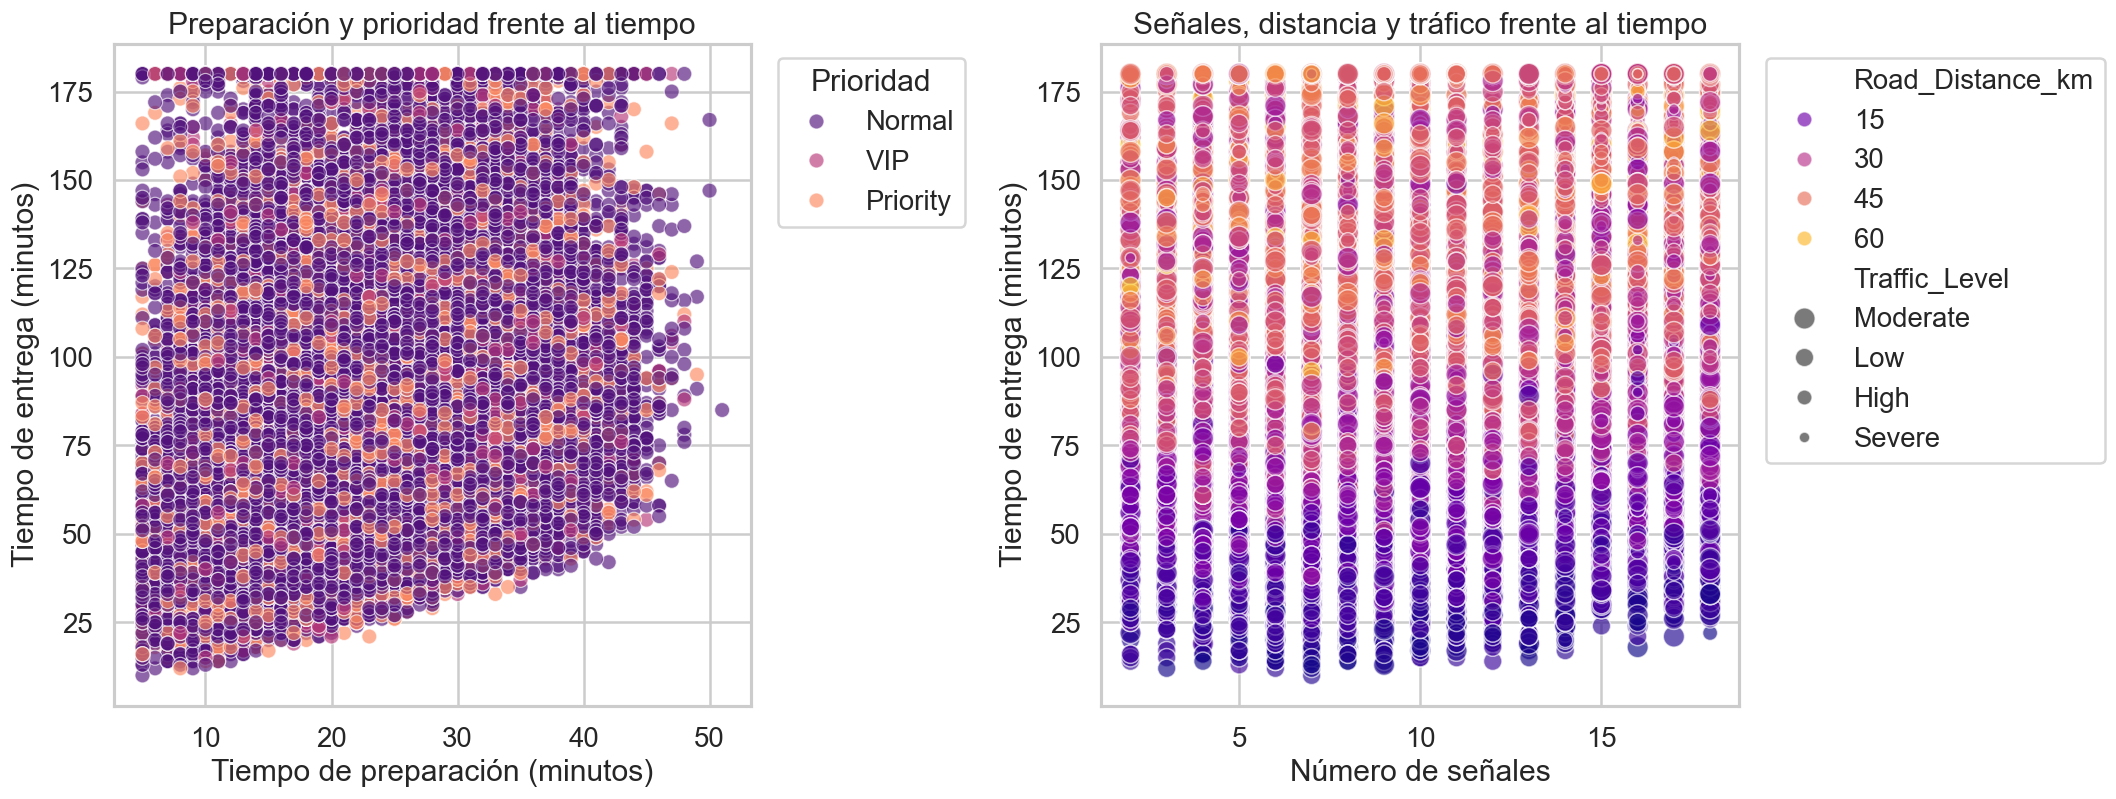

In [11]:
plot_data = df_filtrado.copy()
plot_data['target_time'] = target_time

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=plot_data, x='Preparation_Time_Min', y='target_time', hue='Delivery_Priority', alpha=0.65, palette='magma', ax=axes[0])
axes[0].set_title('Preparación y prioridad frente al tiempo')
axes[0].set_xlabel('Tiempo de preparación (minutos)')
axes[0].set_ylabel('Tiempo de entrega (minutos)')
axes[0].legend(title='Prioridad', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.scatterplot(data=plot_data, x='Number_of_Signals', y='target_time', hue='Road_Distance_km', size='Traffic_Level', alpha=0.65, palette='plasma', ax=axes[1])
axes[1].set_title('Señales, distancia y tráfico frente al tiempo')
axes[1].set_xlabel('Número de señales')
axes[1].set_ylabel('Tiempo de entrega (minutos)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()